# CNN-LSTM OTDR Fault Detection - Single-Input Version

Notebook ini mengimplementasikan modifikasi arsitektur CNN-LSTM dari artikel dengan pendekatan **Single-Input**:
1. **Fitur OTDR**: P1-P30 dan SNR digabung menjadi satu input dengan shape `(31, 1)`.
2. **Backbone CNN-LSTM**: Satu input diproses melalui Conv1D + MaxPooling1D + LSTM.

Output LSTM langsung masuk ke Fully Connected layer dan Softmax classifier tanpa cabang input terpisah.

Metrik evaluasi utama meliputi **F1-Score (Macro)**, **ROC-AUC (Macro)**, dan **Inference Delay (seconds)** yang dipantau setiap epoch menggunakan custom Keras Callback.

## 1. Import Library

In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
# Random seed untuk reproduktifitas
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 2. Setup Folder

In [3]:
folders = [
    "data",
    "data/raw",
    "data/processed",
    "models",
    "reports",
    "reports/figures"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folder berhasil dibuat/diverifikasi.")

Folder berhasil dibuat/diverifikasi.


## 3. Load Dataset

In [ ]:
DATA_PATH = "OTDR_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "OTDR_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = "OTDR_data.csv"

df = pd.read_csv(DATA_PATH)

print("Shape dataset:", df.shape)
display(df.head())
print(df.info())

Shape dataset: (125832, 36)


,Unnamed: 0,SNR,P1,P2,P3,P4,P5,P6,P7,P8,...,P25,P26,P27,P28,P29,P30,Class,Position,Reflectance,loss
0,70519,10.093627,0.989995,0.769634,0.866942,1.000000,0.838370,0.795462,0.801609,0.763259,...,0.345600,0.114946,0.000000,0.381516,0.099061,0.280784,1.0,0.08,0.0,0.112
1,81009,0.219347,0.341150,0.484929,0.689960,0.924820,0.648481,0.196055,0.886128,1.000000,...,0.384524,0.992029,0.488258,0.402361,0.321495,0.679280,3.0,0.11,0.0,0.400
2,62575,9.282432,0.438344,0.981339,0.728630,0.485106,0.359851,0.184697,0.222956,0.437243,...,0.910126,0.964232,0.637623,0.162285,0.138643,0.723457,0.0,0.00,0.0,0.000
3,70401,8.803449,0.674877,0.638932,0.651814,0.716335,0.475147,0.628348,0.626998,0.691957,...,0.411247,0.097255,0.210350,0.263302,0.132508,0.000000,1.0,0.09,0.0,0.100
4,7550,16.485467,0.767071,0.517559,0.115700,0.000000,0.055019,0.258061,0.115876,0.392273,...,0.457824,0.864551,0.704364,0.508301,0.433237,0.028219,0.0,0.00,0.0,0.000


<class 'pandas.DataFrame'>
RangeIndex: 125832 entries, 0 to 125831
Data columns (total 36 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   125832 non-null  int64  
 1   SNR          125832 non-null  float64
 2   P1           125832 non-null  float64
 3   P2           125832 non-null  float64
 4   P3           125832 non-null  float64
 5   P4           125832 non-null  float64
 6   P5           125832 non-null  float64
 7   P6           125832 non-null  float64
 8   P7           125832 non-null  float64
 9   P8           125832 non-null  float64
 10  P9           125832 non-null  float64
 11  P10          125832 non-null  float64
 12  P11          125832 non-null  float64
 13  P12          125832 non-null  float64
 14  P13          125832 non-null  float64
 15  P14          125832 non-null  float64
 16  P15          125832 non-null  float64
 17  P16          125832 non-null  float64
 18  P17          125832 non-null  float

## 4. Data Checking

In [5]:
# Definisi kolom sinyal, SNR, dan target
signal_cols = [f"P{i}" for i in range(1, 31)]
snr_col = "SNR"
target_col = "Class"

# Tampilkan semua nama kolom
print("=" * 60)
print("NAMA KOLOM DATASET")
print("=" * 60)
print(df.columns.tolist())
print(f"\nJumlah kolom: {len(df.columns)}")

NAMA KOLOM DATASET
['Unnamed: 0', 'SNR', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30', 'Class', 'Position', 'Reflectance', 'loss']

Jumlah kolom: 36


In [6]:
# Cek missing values
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_info[missing_info["Missing Count"] > 0])
if missing.sum() == 0:
    print("Tidak ada missing value.")

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
Tidak ada missing value.


In [7]:
# Cek duplicate rows
print("=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
num_duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {num_duplicates}")

DUPLICATE ROWS
Jumlah baris duplikat: 0


In [8]:
# Distribusi target Class
print("=" * 60)
print("DISTRIBUSI TARGET CLASS")
print("=" * 60)
print(df[target_col].value_counts().sort_index())

DISTRIBUSI TARGET CLASS
Class
0.0    16048
1.0    16000
2.0    16000
3.0    16000
4.0    16000
5.0    13849
6.0    16000
7.0    15935
Name: count, dtype: int64


In [9]:
# Statistik deskriptif (termasuk SNR)
print("=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
display(df[signal_cols + [snr_col]].describe())

STATISTIK DESKRIPTIF


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,...,P22,P23,P24,P25,P26,P27,P28,P29,P30,SNR
count,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,...,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000,125832.000000
mean,0.383666,0.379560,0.377179,0.375738,0.376254,0.382815,0.390346,0.399960,0.412891,0.430848,...,0.539401,0.518548,0.497440,0.476285,0.456533,0.437593,0.420615,0.402363,0.389017,12.315957
std,0.343306,0.338766,0.336568,0.332489,0.326922,0.324796,0.319550,0.315327,0.312780,0.312836,...,0.291636,0.294059,0.294876,0.296303,0.296518,0.294765,0.293194,0.295106,0.306531,9.202129
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.041760,0.038821,0.036689,0.040424,0.051494,0.061802,0.079696,0.090327,0.103174,0.126628,...,0.298615,0.270796,0.245755,0.233595,0.215426,0.203007,0.192505,0.169732,0.144702,3.000000
50%,0.320210,0.315812,0.310499,0.308350,0.313471,0.333092,0.351876,0.372897,0.397047,0.428467,...,0.531915,0.497915,0.469838,0.441615,0.416618,0.391529,0.366709,0.347401,0.332184,13.000000
75%,0.690142,0.685213,0.681227,0.669226,0.660253,0.662213,0.658540,0.664620,0.676426,0.698691,...,0.787613,0.770292,0.745594,0.714035,0.683525,0.656642,0.635709,0.617000,0.609878,20.106899
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000


In [10]:
# Validasi kolom wajib
required_cols = signal_cols + [snr_col, target_col]
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan: {missing_cols}")
else:
    print("Semua kolom wajib tersedia.")

Semua kolom wajib tersedia.


## 5. Data Cleaning

In [11]:
# Hapus kolom Unnamed: 0 jika ada
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Hapus baris duplikat
df = df.drop_duplicates()

# Konversi kolom sinyal dan SNR ke numerik
for col in signal_cols + [snr_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Konversi target ke numerik
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

# Isi missing value sinyal dan SNR dengan median masing-masing
df[signal_cols] = df[signal_cols].fillna(df[signal_cols].median())
df[snr_col] = df[snr_col].fillna(df[snr_col].median())

# Hapus baris tanpa target
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype(int)

print("Shape setelah cleaning:", df.shape)
print(df[target_col].value_counts().sort_index())

Shape setelah cleaning: (119008, 35)
Class
0    16044
1    16000
2     9180
3    16000
4    16000
5    13849
6    16000
7    15935
Name: count, dtype: int64


## 6. Label Mapping

In [12]:
label_mapping = {
    0: "Normal",
    1: "Fiber eavesdropping",
    2: "Bad splice",
    3: "Fiber bending",
    4: "Dirty connectors",
    5: "Fiber cut",
    6: "PC connector",
    7: "Reflectors"
}

df["Class_Label"] = df[target_col].map(label_mapping)

print("Label mapping berhasil diterapkan.")
display(df[[target_col, "Class_Label"]].drop_duplicates().sort_values(target_col))

Label mapping berhasil diterapkan.


,Class,Class_Label
2,0,Normal
0,1,Fiber eavesdropping
10,2,Bad splice
1,3,Fiber bending
12,4,Dirty connectors
5,5,Fiber cut
6,6,PC connector
16,7,Reflectors


## 7. EDA Singkat

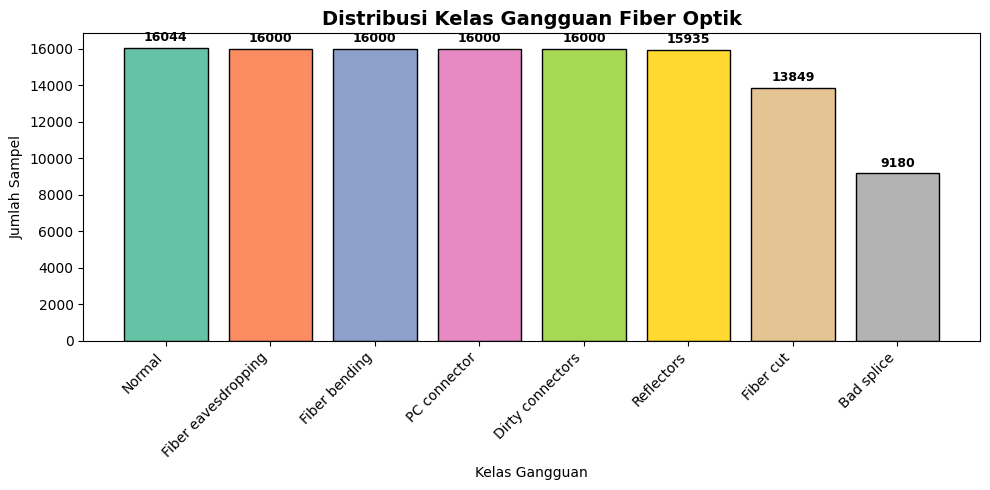

In [13]:
# Distribusi kelas
plt.figure(figsize=(10, 5))
class_counts = df["Class_Label"].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(class_counts)))
bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor="black")

for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.title("Distribusi Kelas Gangguan Fiber Optik", fontsize=14, fontweight="bold")
plt.xlabel("Kelas Gangguan")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/class_distribution.png", dpi=300)
plt.show()

C:\Users\rizki\AppData\Local\Temp\ipykernel_4512\1556169826.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class_Label", y="SNR", data=df, palette="Set2")


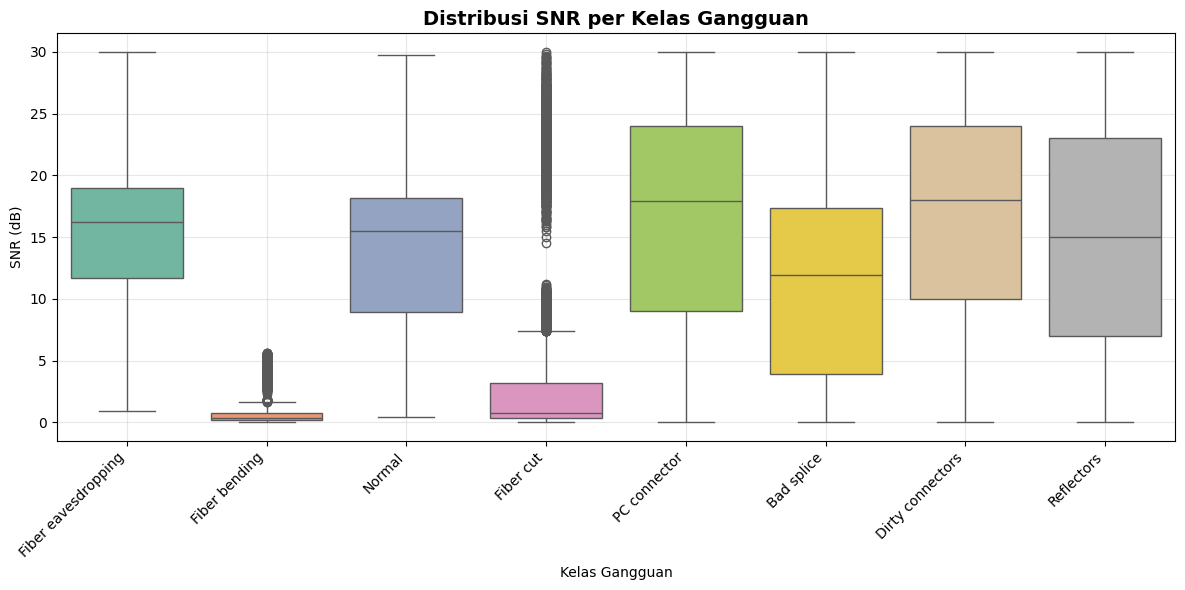

In [14]:
# Distribusi SNR berdasarkan Kelas
plt.figure(figsize=(12, 6))
sns.boxplot(x="Class_Label", y="SNR", data=df, palette="Set2")
plt.title("Distribusi SNR per Kelas Gangguan", fontsize=14, fontweight="bold")
plt.xlabel("Kelas Gangguan")
plt.ylabel("SNR (dB)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/snr_distribution_per_class.png", dpi=300)
plt.show()

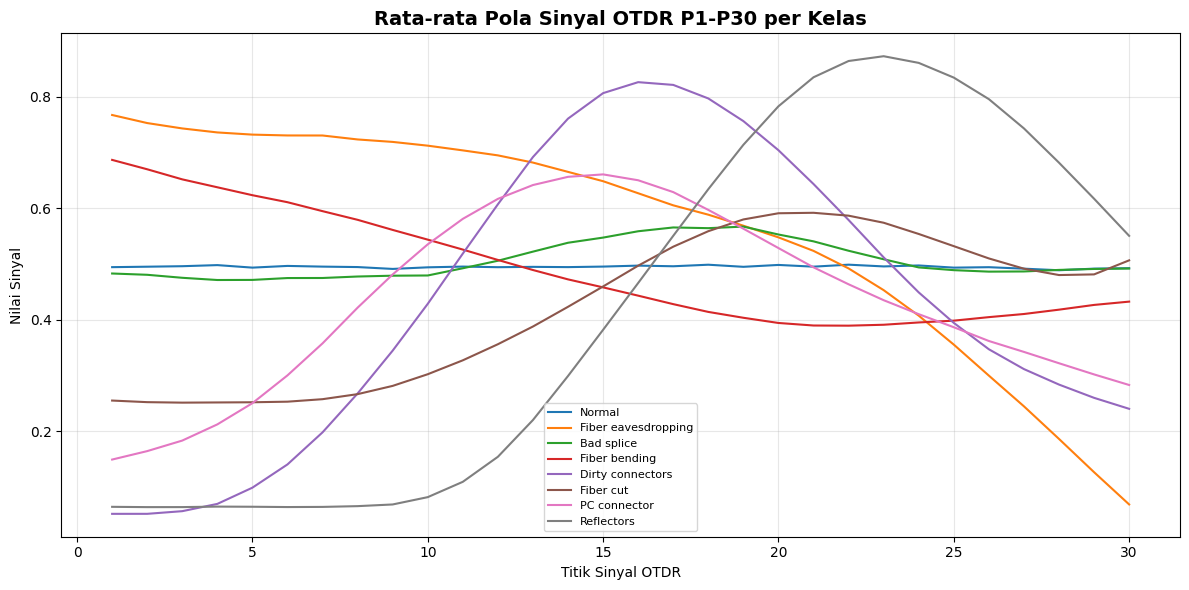

In [15]:
# Rata-rata pola sinyal P1-P30 per kelas
plt.figure(figsize=(12, 6))

for class_id, label in label_mapping.items():
    class_data = df[df[target_col] == class_id][signal_cols]
    mean_signal = class_data.mean(axis=0)
    plt.plot(range(1, 31), mean_signal, label=label)

plt.title("Rata-rata Pola Sinyal OTDR P1-P30 per Kelas", fontsize=14, fontweight="bold")
plt.xlabel("Titik Sinyal OTDR")
plt.ylabel("Nilai Sinyal")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/mean_signal_per_class.png", dpi=300)
plt.show()

## 8. Feature dan Target

In [16]:
# Single input: gabungkan P1-P30 dan SNR dalam satu matriks fitur
feature_cols = signal_cols + [snr_col]
X_features = df[feature_cols].values.astype("float32")
y = df[target_col].values.astype("int32")

print("X_features shape:", X_features.shape)
print("Jumlah fitur:", len(feature_cols))
print("Feature columns:", feature_cols)
print("y shape:", y.shape)
print("Jumlah kelas unik:", len(np.unique(y)))

X_features shape: (119008, 31)
Jumlah fitur: 31
Feature columns: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P24', 'P25', 'P26', 'P27', 'P28', 'P29', 'P30', 'SNR']
y shape: (119008,)
Jumlah kelas unik: 8


## 9. Train-Test Split 70:30 (dan Validation Split)

In [17]:
# Split pertama: 70% Train, 30% Test
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split kedua: Dari 70% Train, bagi 20% untuk Validation Set secara eksplisit
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Train Set (Features) :", X_train_final.shape)
print("Val Set (Features)   :", X_val.shape)
print("Test Set (Features)  :", X_test.shape)
print("y_train_final      :", y_train_final.shape)
print("y_val              :", y_val.shape)
print("y_test             :", y_test.shape)

Train Set (Features) : (66644, 31)
Val Set (Features)   : (16661, 31)
Test Set (Features)  : (35703, 31)
y_train_final      : (66644,)
y_val              : (16661,)
y_test             : (35703,)


## 10. Scaling dan Reshape

In [18]:
# Satu scaler untuk seluruh fitur P1-P30 + SNR
scaler_features = MinMaxScaler()

# Fit & Transform
X_train_scaled = scaler_features.fit_transform(X_train_final)
X_val_scaled = scaler_features.transform(X_val)
X_test_scaled = scaler_features.transform(X_test)

# Reshape fitur ke (samples, timesteps, features) untuk Conv1D + LSTM
n_timesteps = len(feature_cols)
X_train_scaled = X_train_scaled.reshape(-1, n_timesteps, 1)
X_val_scaled = X_val_scaled.reshape(-1, n_timesteps, 1)
X_test_scaled = X_test_scaled.reshape(-1, n_timesteps, 1)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

# Simpan Scaler
joblib.dump(scaler_features, "models/cnn_lstm_single_input_scaler.joblib")
print("Scaler disimpan ke models/.")

X_train_scaled shape: (66644, 31, 1)
X_val_scaled shape: (16661, 31, 1)
X_test_scaled shape: (35703, 31, 1)
Scaler disimpan ke models/.


## 11. Build Single-Input CNN-LSTM Model

Arsitektur:
- **Single Input**: Fitur P1-P30 + SNR dengan shape `(31, 1)` diproses oleh Conv1D (64 filters, kernel size 3, ReLU) → MaxPooling1D (pool size 2) → LSTM (64 units).
- **Fully Connected & Output**: Dense (64 units, ReLU) → Dense (8 units, Softmax).

In [19]:
num_classes = len(np.unique(y))
n_timesteps = len(feature_cols)

# Single input: P1-P30 + SNR
input_features = Input(shape=(n_timesteps, 1), name="otdr_features_input")
x = Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    padding="same",
    name="conv1d_feature_extraction"
)(input_features)

x = MaxPooling1D(
    pool_size=2,
    name="max_pooling_downsampling"
)(x)

x = LSTM(
    units=64,
    name="lstm_sequence_learning"
)(x)

# Fully Connected Layer
x = Dense(
    units=64,
    activation="relu",
    name="fully_connected_layer"
)(x)

output_layer = Dense(
    units=num_classes,
    activation="softmax",
    name="softmax_multiclass_output"
)(x)

# Buat Model
model = Model(
    inputs=input_features,
    outputs=output_layer,
    name="CNN_LSTM_OTDR_SingleInput"
)

model.summary()

Model: "CNN_LSTM_OTDR_SingleInput"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ otdr_features_input             │ (None, 31, 1)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_feature_extraction       │ (None, 31, 64)         │           256 │
│ (Conv1D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling_downsampling        │ (None, 15, 64)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_sequence_learning (LSTM)   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fully_connected_layer (Dense)   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_multiclass_output       │ (None, 8)              │           520 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,960 (148.28 KB)

 Trainable params: 37,960 (148.28 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Compile Model

In [20]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil di-compile.")

Model berhasil di-compile.


## 13. Callbacks (F1, ROC-AUC, Delay Tracking)

Membuat custom Keras callback untuk memantau metrik F1-score, ROC-AUC, dan Inference Delay (Waktu Prediksi) pada validation set di setiap akhir epoch.

In [21]:
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, label_mapping):
        super().__init__()
        self.val_x = val_data[0]  # validation features
        self.val_y = val_data[1]  # val_labels
        self.label_mapping = label_mapping
        self.history = {'val_f1': [], 'val_roc_auc': [], 'val_delay': []}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        
        # Hitung delay inferensi
        start_time = time.time()
        y_prob = self.model.predict(self.val_x, verbose=0)
        delay = time.time() - start_time
        
        y_pred = np.argmax(y_prob, axis=1)
        
        # Hitung F1-score & ROC-AUC
        f1 = f1_score(self.val_y, y_pred, average="macro", zero_division=0)
        try:
            roc_auc = roc_auc_score(self.val_y, y_prob, multi_class="ovr", average="macro")
        except Exception:
            roc_auc = 0.0
            
        # Catat ke history internal
        self.history['val_f1'].append(f1)
        self.history['val_roc_auc'].append(roc_auc)
        self.history['val_delay'].append(delay)
        
        # Tulis ke logs sistem keras
        logs["val_f1"] = f1
        logs["val_roc_auc"] = roc_auc
        logs["val_delay"] = delay
        
        print(f" - val_f1: {f1:.4f} - val_roc_auc: {roc_auc:.4f} - val_delay: {delay:.4f}s")

metrics_callback = MetricsCallback(
    val_data=(X_val_scaled, y_val),
    label_mapping=label_mapping
)

callbacks = [
    metrics_callback,
    EarlyStopping(
        monitor="val_f1",
        patience=10,
        mode="max",
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="models/best_cnn_lstm_single_input.keras",
        monitor="val_f1",
        mode="max",
        save_best_only=True
    )
]

print("Callbacks berhasil di-setup.")

Callbacks berhasil di-setup.


## 14. Training Model

In [22]:
start_train = time.time()

history = model.fit(
    X_train_scaled,
    y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_train
print(f"\nTraining time: {training_time:.2f} seconds")

Epoch 1/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4190 - loss: 1.4488 - val_f1: 0.5824 - val_roc_auc: 0.9265 - val_delay: 2.4623s
521/521 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.5136 - loss: 1.2011 - val_accuracy: 0.6357 - val_loss: 0.9537 - val_f1: 0.5824 - val_roc_auc: 0.9265 - val_delay: 2.4623
Epoch 2/100
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6547 - loss: 0.8764 - val_f1: 0.7091 - val_roc_auc: 0.9627 - val_delay: 2.0899s
521/521 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6892 - loss: 0.7970 - val_accuracy: 0.7433 - val_loss: 0.6683 - val_f1: 0.7091 - val_roc_auc: 0.9627 - val_delay: 2.0899
Epoch 3/100
519/521 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7544 - loss: 0.6364 - val_f1: 0.7585 - val_roc_auc: 0.9720 - val_delay: 2.0847s
521/521 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7648 - loss: 0.6069 - val_accuracy: 0.7887 - val_loss: 0.5612 - val_f1: 0.7585 - val_roc_auc: 0.9720 - val_delay: 2.0847
Epoch 4/100
521/521 ━━

## 15. Visualisasi Training History

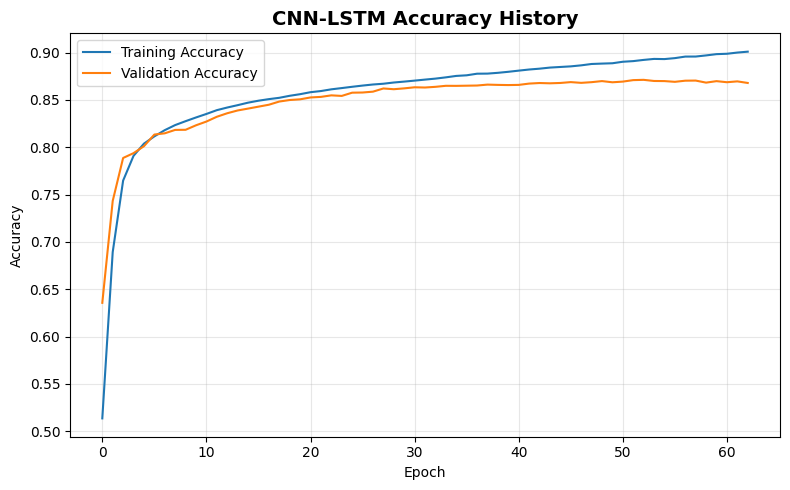

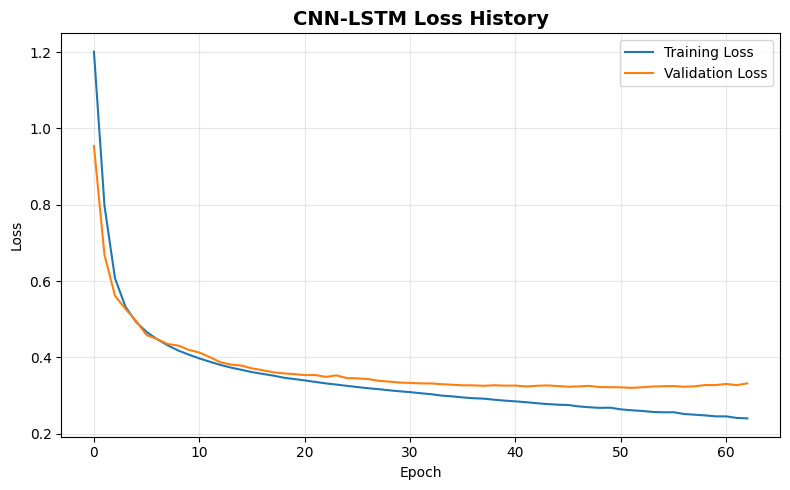

In [23]:
# Grafik Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN-LSTM Accuracy History", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/cnn_lstm_single_input_accuracy.png", dpi=300)
plt.show()

# Grafik Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN-LSTM Loss History", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/cnn_lstm_single_input_loss.png", dpi=300)
plt.show()

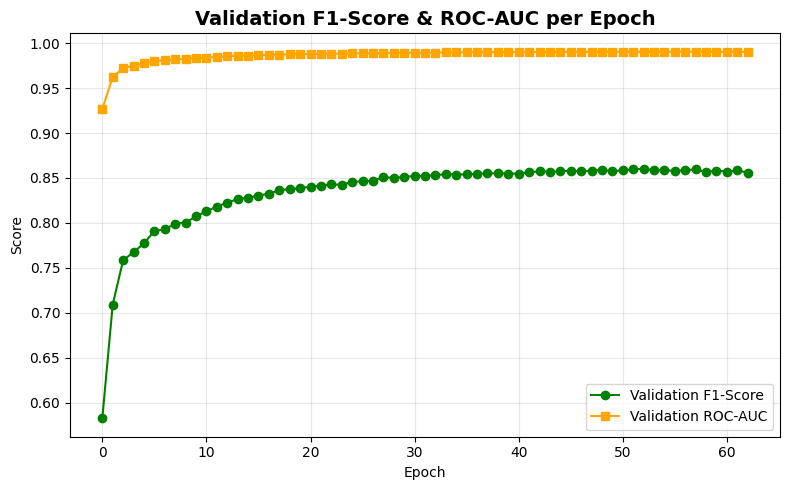

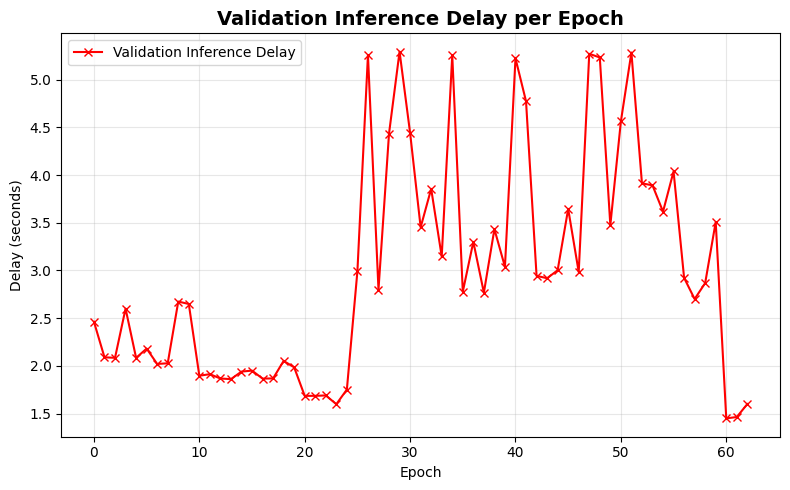

In [24]:
# Grafik F1-Score & ROC-AUC History dari Callback
plt.figure(figsize=(8, 5))
plt.plot(metrics_callback.history["val_f1"], label="Validation F1-Score", color="green", marker="o")
plt.plot(metrics_callback.history["val_roc_auc"], label="Validation ROC-AUC", color="orange", marker="s")
plt.title("Validation F1-Score & ROC-AUC per Epoch", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/cnn_lstm_single_input_metrics.png", dpi=300)
plt.show()

# Grafik Inference Delay per Epoch
plt.figure(figsize=(8, 5))
plt.plot(metrics_callback.history["val_delay"], label="Validation Inference Delay", color="red", marker="x")
plt.title("Validation Inference Delay per Epoch", fontsize=14, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Delay (seconds)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/cnn_lstm_single_input_delay.png", dpi=300)
plt.show()

## 16. Evaluasi Model

In [25]:
# Hitung delay testing secara eksplisit
start_test = time.time()

y_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_prob, axis=1)

testing_time = time.time() - start_test
print(f"Testing delay: {testing_time:.4f} seconds")

1116/1116 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Testing delay: 3.4532 seconds


In [26]:
# Hitung metrik evaluasi final
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")

print("=" * 60)
print("HASIL EVALUASI SINGLE-INPUT CNN-LSTM")
print("=" * 60)
print(f"Accuracy     : {accuracy:.6f}")
print(f"Precision (Macro): {precision:.6f}")
print(f"Recall (Macro)   : {recall:.6f}")
print(f"F1 Score (Macro) : {f1:.6f}")
print(f"ROC-AUC (Macro)  : {roc_auc:.6f}")
print(f"Training Time    : {training_time:.2f} seconds")
print(f"Testing Delay    : {testing_time:.4f} seconds")

HASIL EVALUASI SINGLE-INPUT CNN-LSTM
Accuracy     : 0.871607
Precision (Macro): 0.862127
Recall (Macro)   : 0.859333
F1 Score (Macro) : 0.860103
ROC-AUC (Macro)  : 0.990374
Training Time    : 999.47 seconds
Testing Delay    : 3.4532 seconds


In [27]:
# Classification Report
report = classification_report(
    y_test,
    y_pred,
    target_names=[label_mapping[i] for i in sorted(label_mapping.keys())],
    zero_division=0
)

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(report)

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

             Normal       0.79      0.82      0.80      4813
Fiber eavesdropping       0.95      0.94      0.94      4800
         Bad splice       0.70      0.65      0.67      2754
      Fiber bending       0.91      0.91      0.91      4800
   Dirty connectors       0.93      0.91      0.92      4800
          Fiber cut       0.78      0.85      0.82      4155
       PC connector       0.94      0.87      0.90      4800
         Reflectors       0.90      0.93      0.92      4781

           accuracy                           0.87     35703
          macro avg       0.86      0.86      0.86     35703
       weighted avg       0.87      0.87      0.87     35703



## 17. Confusion Matrix

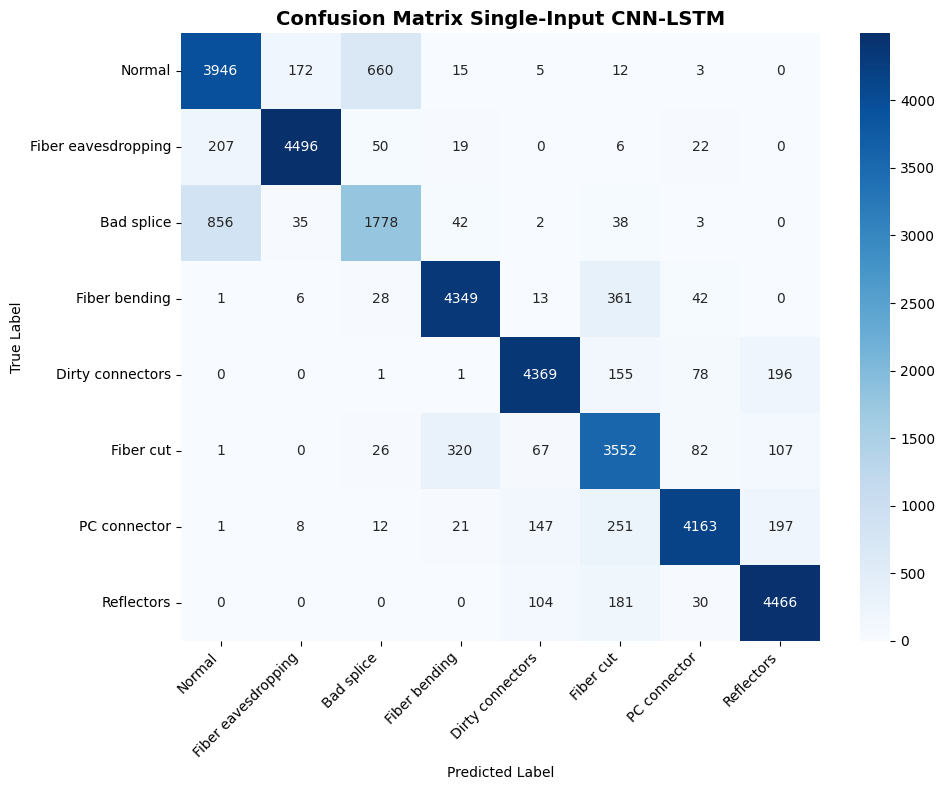

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[label_mapping[i] for i in sorted(label_mapping.keys())],
    yticklabels=[label_mapping[i] for i in sorted(label_mapping.keys())]
)

plt.title("Confusion Matrix Single-Input CNN-LSTM", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("reports/figures/cnn_lstm_single_input_confusion_matrix.png", dpi=300)
plt.show()

## 18. ROC Curve Multi-Class

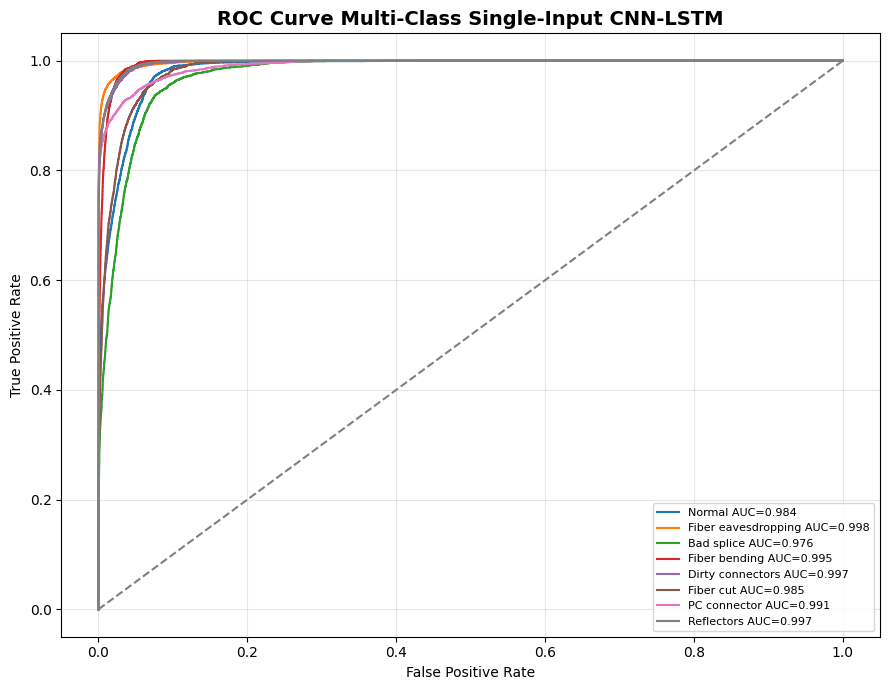

In [29]:
classes = sorted(label_mapping.keys())
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(9, 7))

for i, class_id in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"{label_mapping[class_id]} AUC={roc_auc_class:.3f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Multi-Class Single-Input CNN-LSTM", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/cnn_lstm_single_input_roc_curve.png", dpi=300)
plt.show()

## 19. Feature Importance

Baseline F1 macro pada subset: 0.864969
Baseline accuracy pada subset: 0.876400
Feature importance disimpan ke reports/cnn_lstm_single_input_feature_importance.csv


,feature,baseline_f1_macro,permuted_f1_macro_mean,permuted_f1_macro_std,importance_f1_drop,baseline_accuracy,permuted_accuracy_mean,permuted_accuracy_std,importance_accuracy_drop
0,SNR,0.864969,0.531941,0.002661,0.333028,0.8764,0.534600,0.002142,0.341800
1,P2,0.864969,0.692612,0.003973,0.172357,0.8764,0.696733,0.003616,0.179667
2,P4,0.864969,0.703465,0.002932,0.161503,0.8764,0.703533,0.002368,0.172867
3,P3,0.864969,0.708622,0.003374,0.156347,0.8764,0.712133,0.003549,0.164267
4,P1,0.864969,0.713757,0.000435,0.151211,0.8764,0.719067,0.000680,0.157333
5,P6,0.864969,0.719969,0.002735,0.145000,0.8764,0.719733,0.003013,0.156667
6,P5,0.864969,0.720634,0.000939,0.144335,0.8764,0.723733,0.000094,0.152667
7,P7,0.864969,0.727882,0.004736,0.137087,0.8764,0.730400,0.004836,0.146000
8,P8,0.864969,0.728962,0.000299,0.136007,0.8764,0.730867,0.001236,0.145533
9,P9,0.864969,0.731682,0.004168,0.133287,0.8764,0.735533,0.003434,0.140867


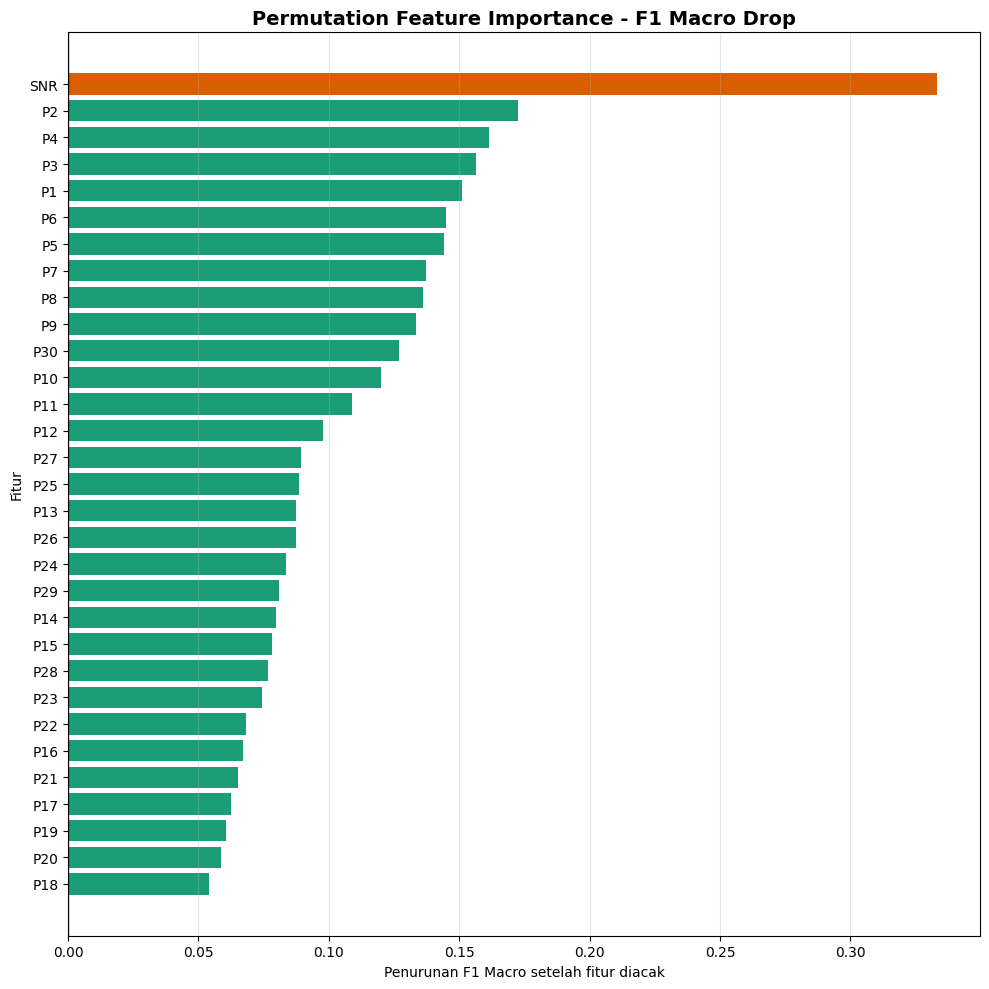

In [30]:
# Permutation Feature Importance untuk model CNN-LSTM single-input
# Setiap fitur diacak satu per satu, lalu dihitung penurunan performa model.
importance_sample_size = min(5000, X_test_scaled.shape[0])
importance_repeats = 3
rng = np.random.default_rng(RANDOM_STATE)

importance_idx = rng.choice(
    X_test_scaled.shape[0],
    size=importance_sample_size,
    replace=False
)

X_importance = X_test_scaled[importance_idx].copy()
y_importance = y_test[importance_idx]
baseline_pred = y_pred[importance_idx]

baseline_f1 = f1_score(
    y_importance,
    baseline_pred,
    average="macro",
    zero_division=0
)
baseline_acc = accuracy_score(y_importance, baseline_pred)

importance_rows = []

for feature_idx, feature_name in enumerate(feature_cols):
    repeat_f1_scores = []
    repeat_acc_scores = []

    for repeat in range(importance_repeats):
        X_permuted = X_importance.copy()
        X_permuted[:, feature_idx, 0] = rng.permutation(X_permuted[:, feature_idx, 0])

        permuted_prob = model.predict(X_permuted, verbose=0)
        permuted_pred = np.argmax(permuted_prob, axis=1)

        repeat_f1_scores.append(
            f1_score(
                y_importance,
                permuted_pred,
                average="macro",
                zero_division=0
            )
        )
        repeat_acc_scores.append(accuracy_score(y_importance, permuted_pred))

    permuted_f1_mean = float(np.mean(repeat_f1_scores))
    permuted_acc_mean = float(np.mean(repeat_acc_scores))

    importance_rows.append({
        "feature": feature_name,
        "baseline_f1_macro": baseline_f1,
        "permuted_f1_macro_mean": permuted_f1_mean,
        "permuted_f1_macro_std": float(np.std(repeat_f1_scores)),
        "importance_f1_drop": baseline_f1 - permuted_f1_mean,
        "baseline_accuracy": baseline_acc,
        "permuted_accuracy_mean": permuted_acc_mean,
        "permuted_accuracy_std": float(np.std(repeat_acc_scores)),
        "importance_accuracy_drop": baseline_acc - permuted_acc_mean
    })

feature_importance_df = pd.DataFrame(importance_rows).sort_values(
    by="importance_f1_drop",
    ascending=False
).reset_index(drop=True)

feature_importance_df.to_csv(
    "reports/cnn_lstm_single_input_feature_importance.csv",
    index=False
)

print("Baseline F1 macro pada subset:", f"{baseline_f1:.6f}")
print("Baseline accuracy pada subset:", f"{baseline_acc:.6f}")
print("Feature importance disimpan ke reports/cnn_lstm_single_input_feature_importance.csv")
display(feature_importance_df)

plot_df = feature_importance_df.sort_values("importance_f1_drop", ascending=True)
colors = ["#d95f02" if feature == snr_col else "#1b9e77" for feature in plot_df["feature"]]

plt.figure(figsize=(10, 10))
plt.barh(plot_df["feature"], plot_df["importance_f1_drop"], color=colors)
plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.title("Permutation Feature Importance - F1 Macro Drop", fontsize=14, fontweight="bold")
plt.xlabel("Penurunan F1 Macro setelah fitur diacak")
plt.ylabel("Fitur")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("reports/figures/cnn_lstm_single_input_feature_importance.png", dpi=300)
plt.show()

## 20. Simpan Model dan Metadata

In [31]:
# Simpan model final
model.save("models/final_cnn_lstm_single_input.keras")
print("Model disimpan ke models/final_cnn_lstm_single_input.keras")

Model disimpan ke models/final_cnn_lstm_single_input.keras


In [32]:
# Simpan metadata
metadata = {
    "model_name": "CNN_LSTM_OTDR_SingleInput",
    "feature_cols": feature_cols,
    "signal_cols": signal_cols,
    "snr_col": snr_col,
    "target_col": target_col,
    "label_mapping": label_mapping,
    "input_shape": (len(feature_cols), 1),
    "num_classes": num_classes,
    "architecture": [
        "Single input P1-P30 + SNR with shape (31, 1)",
        "Conv1D 64 filters, kernel size 3, ReLU",
        "MaxPooling1D pool size 2 on Conv1D output",
        "LSTM 64 units on MaxPool output",
        "Dense 64 ReLU on LSTM output",
        "Dense 8 Softmax output"
    ]
}

joblib.dump(metadata, "models/cnn_lstm_single_input_metadata.joblib")
print("Metadata disimpan ke models/cnn_lstm_single_input_metadata.joblib")

Metadata disimpan ke models/cnn_lstm_single_input_metadata.joblib


## 21. Fungsi Rekomendasi Tindakan

In [33]:
def fault_recommendation(class_id):
    """Memberikan rekomendasi tindakan berdasarkan kelas gangguan yang terdeteksi."""
    recommendations = {
        0: "Jaringan berjalan normal. Lanjutkan monitoring berkala.",
        1: "Cek potensi penyadapan fiber, aktifkan pengamanan kanal, dan lakukan inspeksi fisik.",
        2: "Cek titik sambungan dan lakukan resplicing.",
        3: "Cek jalur kabel dan perbaiki radius bending.",
        4: "Bersihkan atau ganti konektor.",
        5: "Lakukan reroute ke backup link dan buat tiket perbaikan fisik.",
        6: "Bersihkan atau ganti PC connector.",
        7: "Gunakan reflector sebagai penanda cabang PON dan validasi posisinya."
    }

    return recommendations.get(int(class_id), "Kelas tidak dikenal. Lakukan pemeriksaan manual.")

# Test fungsi
for k, v in label_mapping.items():
    print(f"Class {k} ({v}): {fault_recommendation(k)}")

Class 0 (Normal): Jaringan berjalan normal. Lanjutkan monitoring berkala.
Class 1 (Fiber eavesdropping): Cek potensi penyadapan fiber, aktifkan pengamanan kanal, dan lakukan inspeksi fisik.
Class 2 (Bad splice): Cek titik sambungan dan lakukan resplicing.
Class 3 (Fiber bending): Cek jalur kabel dan perbaiki radius bending.
Class 4 (Dirty connectors): Bersihkan atau ganti konektor.
Class 5 (Fiber cut): Lakukan reroute ke backup link dan buat tiket perbaikan fisik.
Class 6 (PC connector): Bersihkan atau ganti PC connector.
Class 7 (Reflectors): Gunakan reflector sebagai penanda cabang PON dan validasi posisinya.


## 22. Inference Function (Single-Input)

In [34]:
def predict_cnn_lstm_single_input(input_data):
    """Fungsi prediksi untuk model CNN-LSTM single-input dengan fitur P1-P30 dan SNR.
    
    Args:
        input_data: Dictionary atau DataFrame berisi kolom P1-P30 dan SNR.
    
    Returns:
        Dictionary berisi predicted_class, predicted_label, confidence,
        dan recommendation.
    """
    from tensorflow.keras.models import load_model

    model = load_model("models/final_cnn_lstm_single_input.keras")
    scaler_features = joblib.load("models/cnn_lstm_single_input_scaler.joblib")
    metadata = joblib.load("models/cnn_lstm_single_input_metadata.joblib")

    feature_cols = metadata["feature_cols"]
    signal_cols = metadata["signal_cols"]
    snr_col = metadata["snr_col"]
    label_mapping = metadata["label_mapping"]

    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data.copy()
    else:
        raise ValueError("Input harus berupa dictionary atau DataFrame.")

    missing_cols = [col for col in feature_cols if col not in input_df.columns]
    if missing_cols:
        raise ValueError(f"Kolom input kurang: {missing_cols}")

    # Scale dan reshape menjadi satu input (samples, 31, 1)
    X_new = input_df[feature_cols].values.astype("float32")

    X_new_scaled = scaler_features.transform(X_new)
    X_new_scaled = X_new_scaled.reshape(-1, len(feature_cols), 1)

    # Predict
    prob = model.predict(X_new_scaled)
    pred_class = int(np.argmax(prob, axis=1)[0])
    confidence = float(np.max(prob))

    result = {
        "predicted_class": pred_class,
        "predicted_label": label_mapping[pred_class],
        "confidence": confidence,
        "recommendation": fault_recommendation(pred_class)
    }

    return result

print("Fungsi predict_cnn_lstm_single_input() siap digunakan.")

Fungsi predict_cnn_lstm_single_input() siap digunakan.


## 23. Contoh Prediksi

In [35]:
# Ambil 1 sampel dari data test
sample_data = pd.DataFrame(X_test[:1], columns=feature_cols)

print("Input data:")
display(sample_data)

prediction = predict_cnn_lstm_single_input(sample_data)

print("\n" + "=" * 60)
print("HASIL PREDIKSI")
print("=" * 60)
print(f"Predicted Class : {prediction['predicted_class']}")
print(f"Predicted Label : {prediction['predicted_label']}")
print(f"Confidence      : {prediction['confidence']:.4f}")
print(f"Recommendation  : {prediction['recommendation']}")
print(f"\nActual Class    : {y_test[0]} ({label_mapping[y_test[0]]})")

Input data:


,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,...,P22,P23,P24,P25,P26,P27,P28,P29,P30,SNR
0,0.87536,0.61291,0.561618,0.560298,0.538518,0.116754,0.463124,0.460681,0.662357,0.069547,...,0.192664,0.867871,0.548648,0.521142,0.0,0.095412,0.252324,0.597733,0.28135,0.028254


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step

HASIL PREDIKSI
Predicted Class : 3
Predicted Label : Fiber bending
Confidence      : 0.9627
Recommendation  : Cek jalur kabel dan perbaiki radius bending.

Actual Class    : 3 (Fiber bending)


## 24. Export Hasil Evaluasi

In [36]:
# Simpan evaluasi ke CSV
evaluation_result = pd.DataFrame([{
    "model_name": "CNN-LSTM Single-Input (P1-P30 + SNR)",
    "accuracy": accuracy,
    "precision_macro": precision,
    "recall_macro": recall,
    "f1_macro": f1,
    "roc_auc_macro": roc_auc,
    "training_time_sec": training_time,
    "testing_delay_sec": testing_time
}])

evaluation_result.to_csv("reports/cnn_lstm_single_input_evaluation.csv", index=False)
print("Evaluasi disimpan ke reports/cnn_lstm_single_input_evaluation.csv")

# Simpan classification report
with open("reports/cnn_lstm_single_input_classification_report.txt", "w") as f:
    f.write(report)
print("Classification report disimpan ke reports/cnn_lstm_single_input_classification_report.txt")

# Simpan confusion matrix
pd.DataFrame(cm).to_csv("reports/cnn_lstm_single_input_confusion_matrix.csv", index=False)
print("Confusion matrix disimpan ke reports/cnn_lstm_single_input_confusion_matrix.csv")

# Tampilkan ringkasan evaluasi
display(evaluation_result)

Evaluasi disimpan ke reports/cnn_lstm_single_input_evaluation.csv
Classification report disimpan ke reports/cnn_lstm_single_input_classification_report.txt
Confusion matrix disimpan ke reports/cnn_lstm_single_input_confusion_matrix.csv


,model_name,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro,training_time_sec,testing_delay_sec
0,CNN-LSTM Single-Input (P1-P30 + SNR),0.871607,0.862127,0.859333,0.860103,0.990374,999.472512,3.4532


---

## Ringkasan

### Arsitektur Model
Model CNN-LSTM ini menggunakan satu input fitur gabungan:
- **Fitur OTDR**: P1-P30 + SNR (shape `(31, 1)`) → Conv1D (64, kernel 3, ReLU) → MaxPooling1D (pool 2) → LSTM (64)
- **Classifier**: Dense (64, ReLU) → Dense (8, Softmax)

### Output yang Dihasilkan
| File | Lokasi |
|------|--------|
| Best model (checkpoint) | `models/best_cnn_lstm_single_input.keras` |
| Final model | `models/final_cnn_lstm_single_input.keras` |
| Feature Scaler | `models/cnn_lstm_single_input_scaler.joblib` |
| Metadata | `models/cnn_lstm_single_input_metadata.joblib` |
| Evaluasi CSV | `reports/cnn_lstm_single_input_evaluation.csv` |
| Classification report | `reports/cnn_lstm_single_input_classification_report.txt` |
| Confusion matrix CSV | `reports/cnn_lstm_single_input_confusion_matrix.csv` |
| Feature importance CSV | `reports/cnn_lstm_single_input_feature_importance.csv` |
| Grafik accuracy | `reports/figures/cnn_lstm_single_input_accuracy.png` |
| Grafik loss | `reports/figures/cnn_lstm_single_input_loss.png` |
| Grafik F1 & ROC-AUC | `reports/figures/cnn_lstm_single_input_metrics.png` |
| Grafik delay | `reports/figures/cnn_lstm_single_input_delay.png` |
| Grafik confusion matrix | `reports/figures/cnn_lstm_single_input_confusion_matrix.png` |
| Grafik ROC curve | `reports/figures/cnn_lstm_single_input_roc_curve.png` |
| Grafik feature importance | `reports/figures/cnn_lstm_single_input_feature_importance.png` |